# 🏢 Vendor Performance Data Analytics — End-to-End Project

**Tech Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · SQLite

**Dataset:** `vendor_sales_summary.csv` — 2,000 transaction records across 10 vendors, 7 product categories (2023)

---
### Project Workflow
1. Data Loading & Inspection
2. Data Cleaning & Feature Engineering
3. Exploratory Data Analysis (EDA)
4. Visualizations (12 charts)
5. Vendor KPI Summary
6. Business Insights & Recommendations


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='Set2')

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## 2. Load Dataset

In [ ]:
df = pd.read_csv('../data/vendor_sales_summary.csv')
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (2000, 11)


  VendorName    Brand         Category  PurchasePrice  ActualPrice  QuantitySold  QuantityOnHand   TotalSales  TotalPurchaseCost  GrossProfit PurchaseDate
0  Global Mart  Brand G      Electronics         274.73       518.23          187           345  96939.01          51374.51     45564.50   2023-07-25
...

## 3. Data Inspection

In [ ]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   VendorName         2000 non-null   object 
 1   Brand              2000 non-null   object 
 2   Category           2000 non-null   object 
 3   PurchasePrice      2000 non-null   float64
 4   ActualPrice        2000 non-null   float64
 5   QuantitySold       2000 non-null   int64  
 6   QuantityOnHand     2000 non-null   int64  
 7   TotalSales         2000 non-null   float64
 8   TotalPurchaseCost  2000 non-null   float64
 9   GrossProfit        2000 non-null   float64
10   PurchaseDate       2000 non-null   object 
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


In [ ]:
print('Missing Values:\n')
print(df.isnull().sum())

Missing Values:

VendorName           0
Brand                0
Category             0
PurchasePrice        0
ActualPrice          0
QuantitySold         0
QuantityOnHand       0
TotalSales           0
TotalPurchaseCost    0
GrossProfit          0
PurchaseDate         0
dtype: int64


In [ ]:
df.describe().T

       count     mean      std      min     25%      50%      75%      max
PurchasePrice  2000  256.61  140.11    10.03  132.78   257.14   381.34   499.97
ActualPrice    2000  439.80  262.96    11.11  220.03   426.77   644.19  1249.95
...

## 4. Data Cleaning & Feature Engineering

In [ ]:
# Convert PurchaseDate to datetime
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# Extract date features
df['Month']     = df['PurchaseDate'].dt.month
df['MonthName'] = df['PurchaseDate'].dt.strftime('%b')
df['Quarter']   = df['PurchaseDate'].dt.quarter
df['Year']      = df['PurchaseDate'].dt.year

# Feature Engineering: Profit Margin
df['ProfitMargin'] = ((df['GrossProfit'] / df['TotalSales']) * 100).round(2)

# Price Markup Ratio
df['MarkupRatio'] = (df['ActualPrice'] / df['PurchasePrice']).round(3)

print('Feature engineering complete!')
print(f'New columns: {list(df.columns[-6:])}')
df[['VendorName','TotalSales','GrossProfit','ProfitMargin','MarkupRatio']].head()

Feature engineering complete!
New columns: ['Month', 'MonthName', 'Quarter', 'Year', 'ProfitMargin', 'MarkupRatio']


In [ ]:
# Save cleaned dataset
df.to_csv('../data/vendor_sales_cleaned.csv', index=False)
print('Cleaned dataset saved to: data/vendor_sales_cleaned.csv ✅')

Cleaned dataset saved to: data/vendor_sales_cleaned.csv ✅


## 5. Exploratory Data Analysis — Visualizations

### 5.1 Total Sales by Vendor

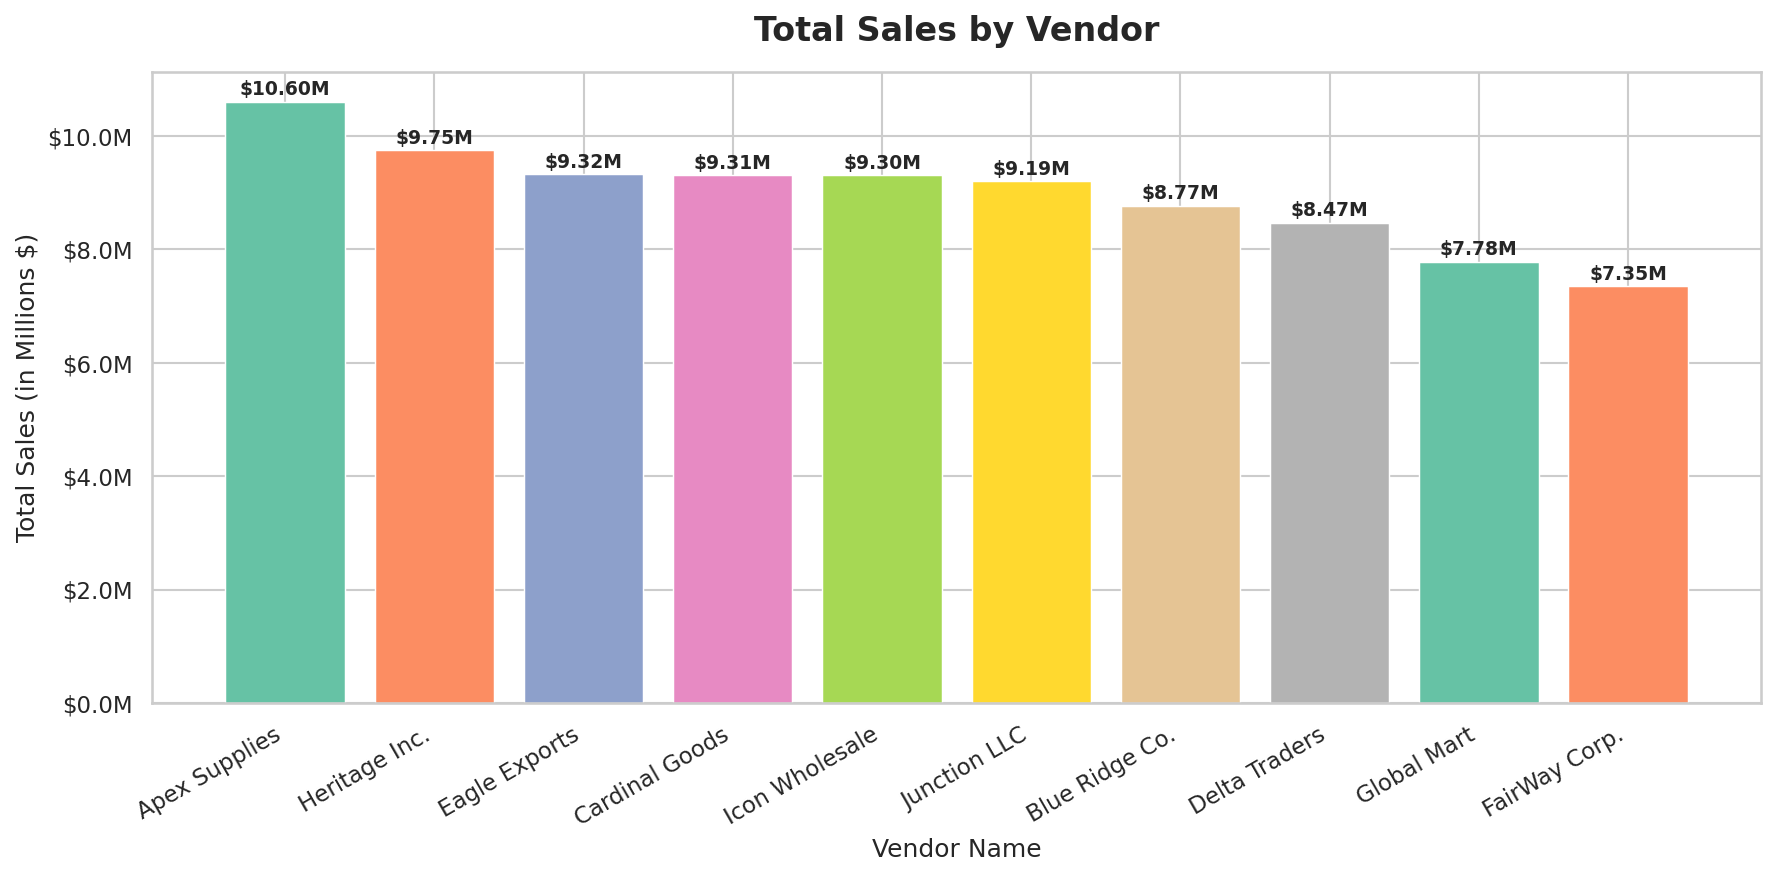

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
vendor_sales = df.groupby('VendorName')['TotalSales'].sum().sort_values(ascending=False)
colors = sns.color_palette('Set2', len(vendor_sales))
bars = ax.bar(vendor_sales.index, vendor_sales.values / 1e6, color=colors, edgecolor='white')
ax.set_title('Total Sales by Vendor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Vendor Name', fontsize=12)
ax.set_ylabel('Total Sales (in Millions $)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.xticks(rotation=30, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'${bar.get_height():.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../output_graphs/01_total_sales_by_vendor.png', bbox_inches='tight')
plt.show()

### 5.2 Total Gross Profit by Vendor

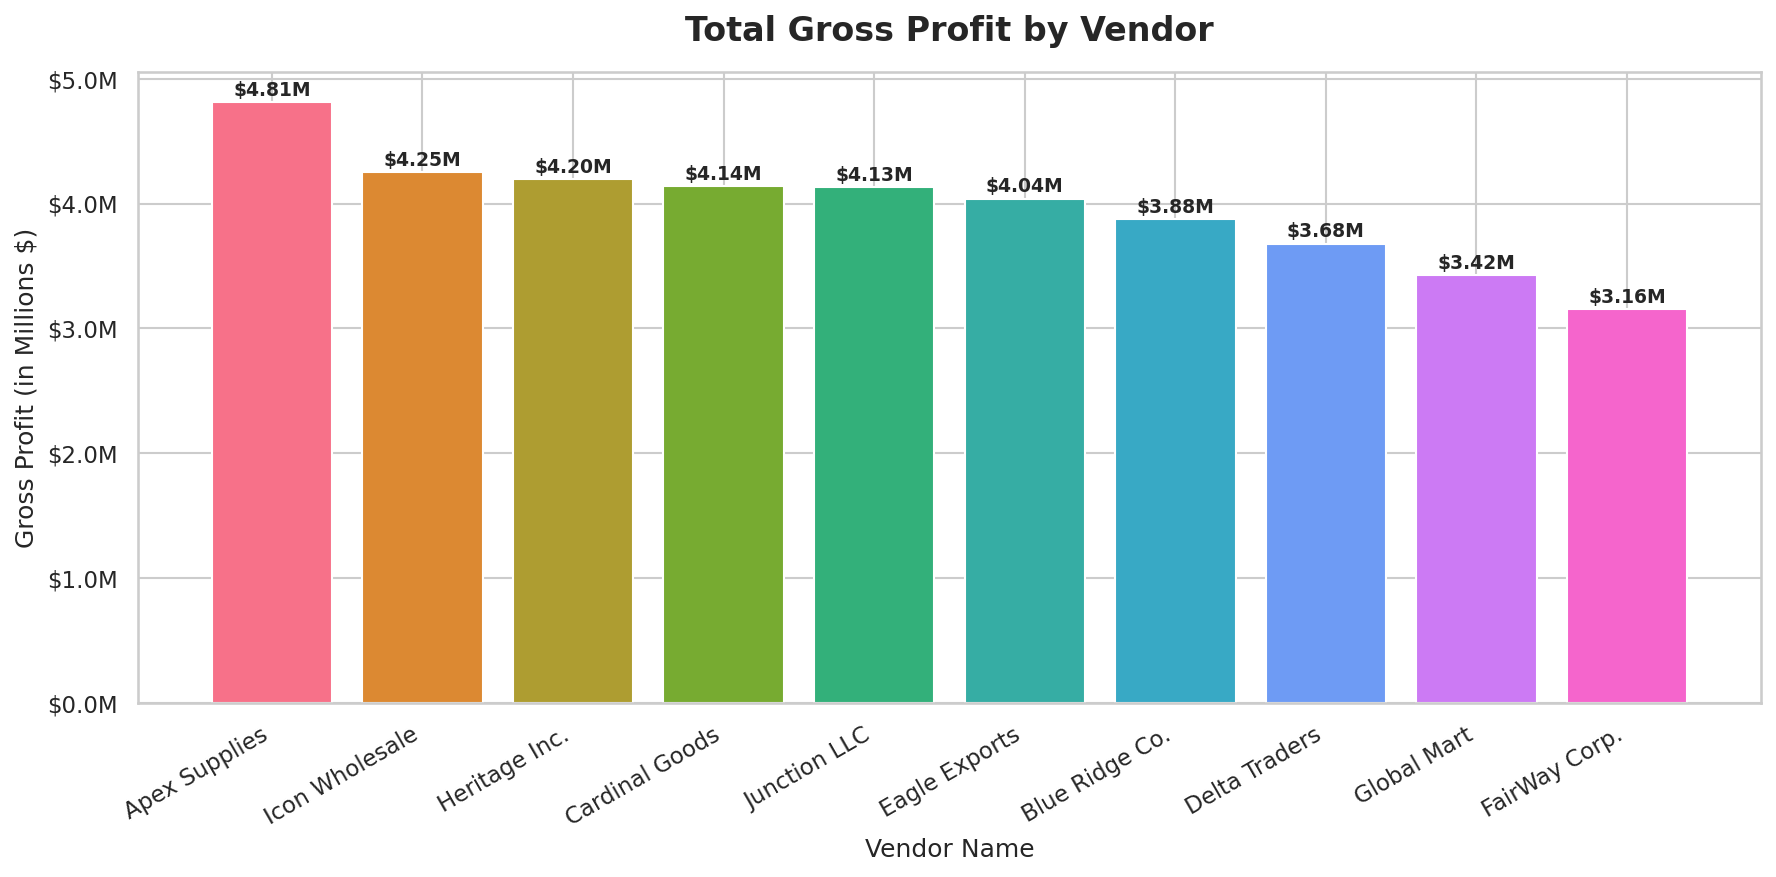

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
vendor_profit = df.groupby('VendorName')['GrossProfit'].sum().sort_values(ascending=False)
bars2 = ax.bar(vendor_profit.index, vendor_profit.values / 1e6,
               color=sns.color_palette('husl', len(vendor_profit)), edgecolor='white')
ax.set_title('Total Gross Profit by Vendor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Vendor Name', fontsize=12)
ax.set_ylabel('Gross Profit (in Millions $)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.xticks(rotation=30, ha='right')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'${bar.get_height():.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../output_graphs/02_gross_profit_by_vendor.png', bbox_inches='tight')
plt.show()

### 5.3 Average Profit Margin by Vendor

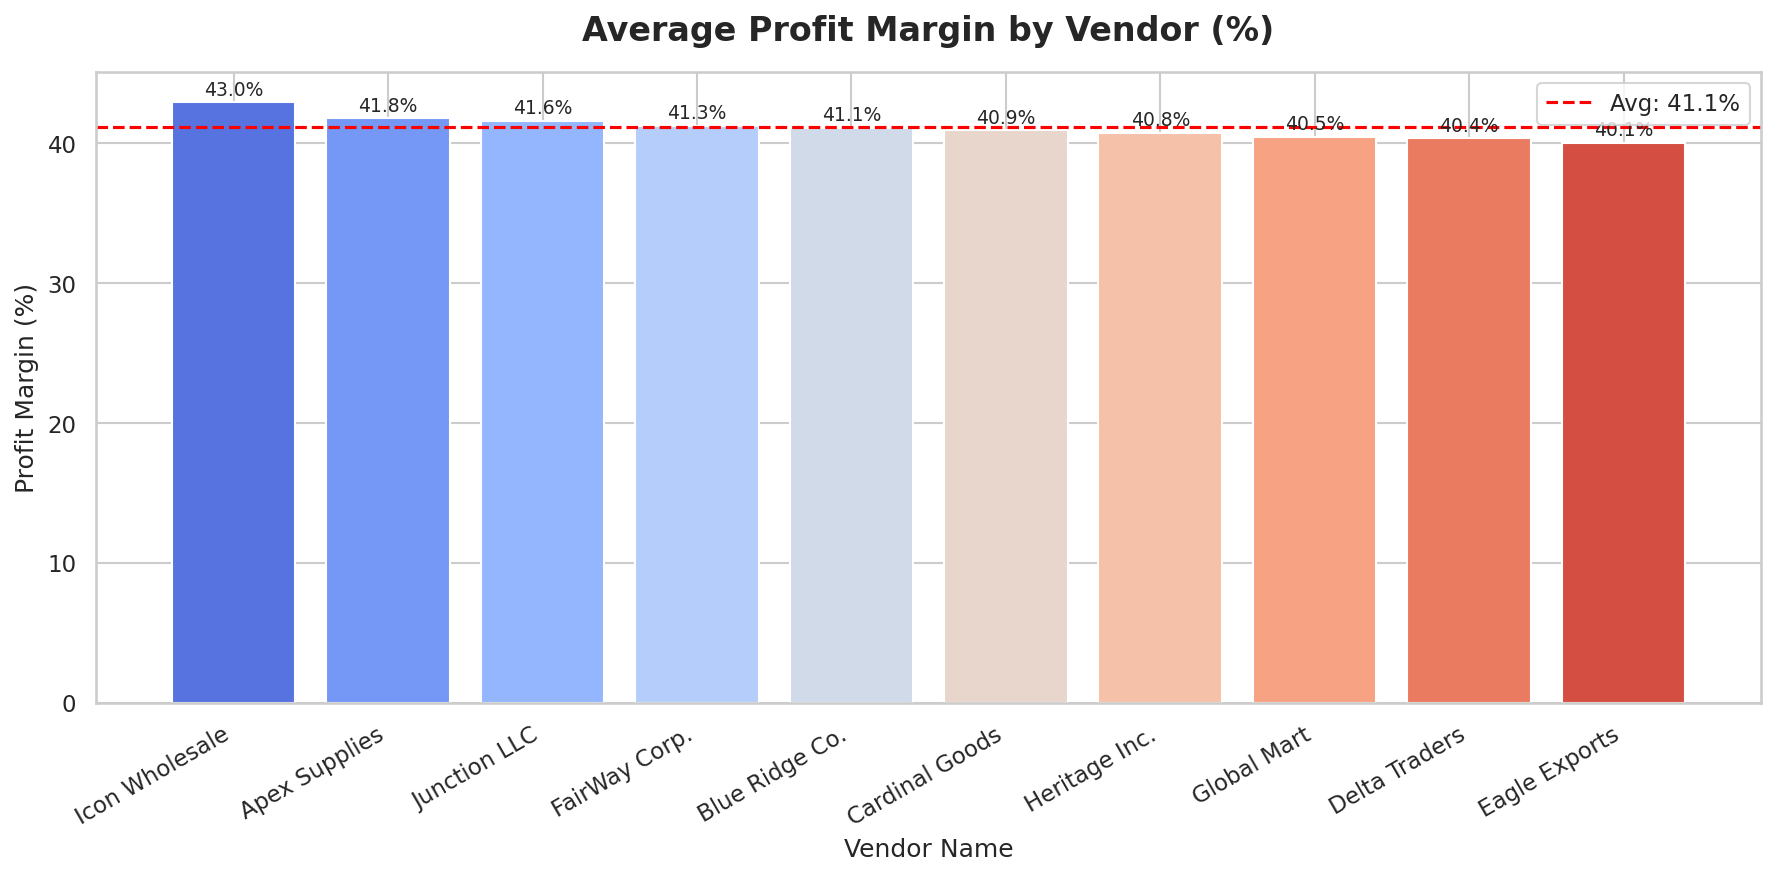

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
vendor_margin = df.groupby('VendorName')['ProfitMargin'].mean().sort_values(ascending=False)
bars3 = ax.bar(vendor_margin.index, vendor_margin.values,
               color=sns.color_palette('coolwarm', len(vendor_margin)), edgecolor='white')
ax.set_title('Average Profit Margin by Vendor (%)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Vendor Name', fontsize=12)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
ax.axhline(vendor_margin.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {vendor_margin.mean():.1f}%')
ax.legend()
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../output_graphs/03_profit_margin_by_vendor.png', bbox_inches='tight')
plt.show()

### 5.4 Total Sales by Category

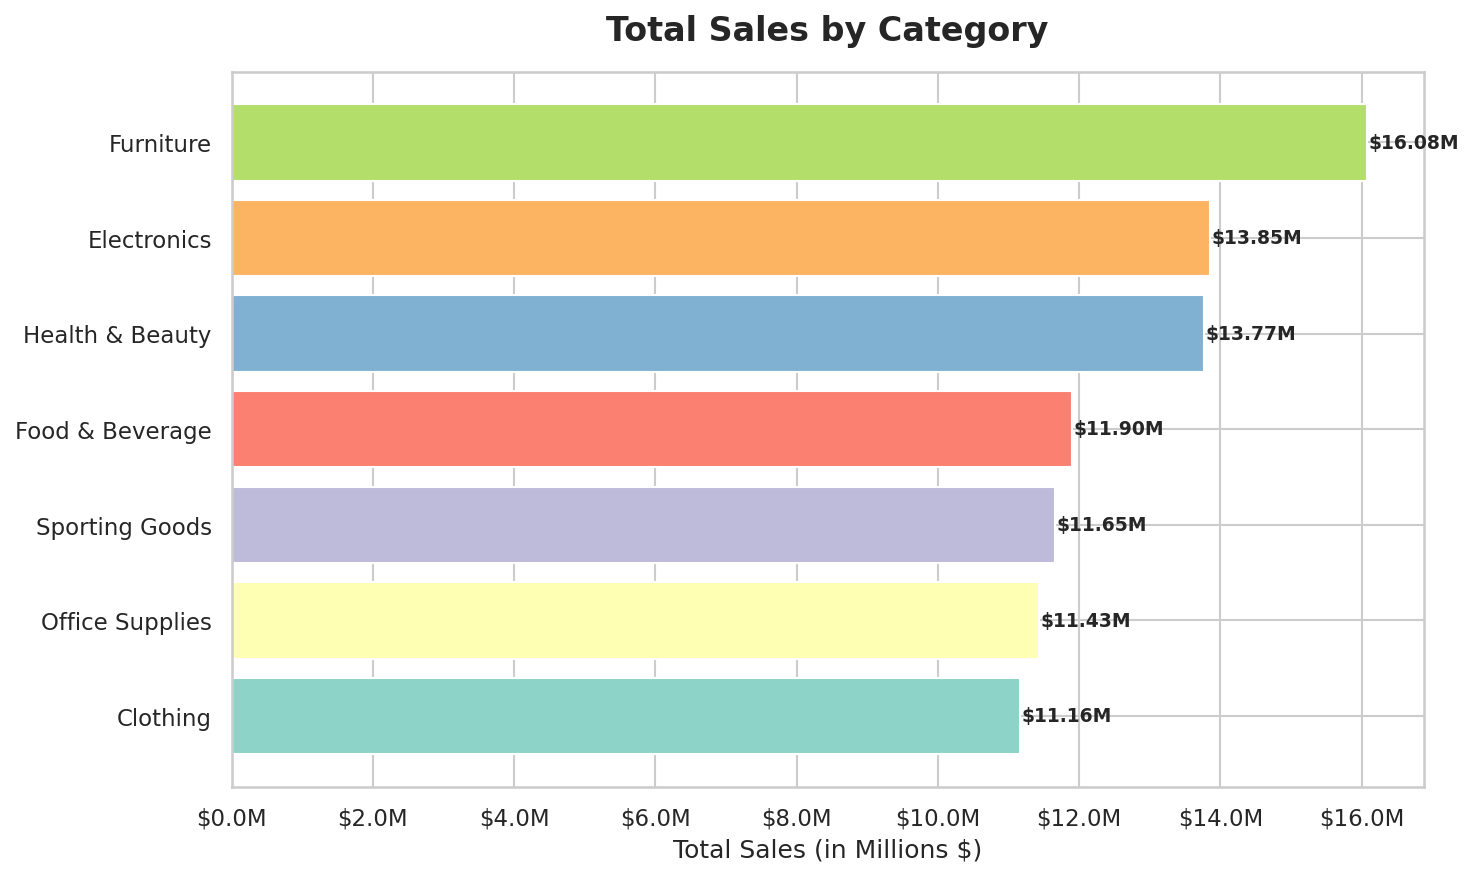

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
cat_sales = df.groupby('Category')['TotalSales'].sum().sort_values(ascending=True)
bars4 = ax.barh(cat_sales.index, cat_sales.values / 1e6,
                color=sns.color_palette('Set3', len(cat_sales)), edgecolor='white')
ax.set_title('Total Sales by Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales (in Millions $)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
for bar in bars4:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():.2f}M', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../output_graphs/04_sales_by_category.png', bbox_inches='tight')
plt.show()

### 5.5 Monthly Sales Trend

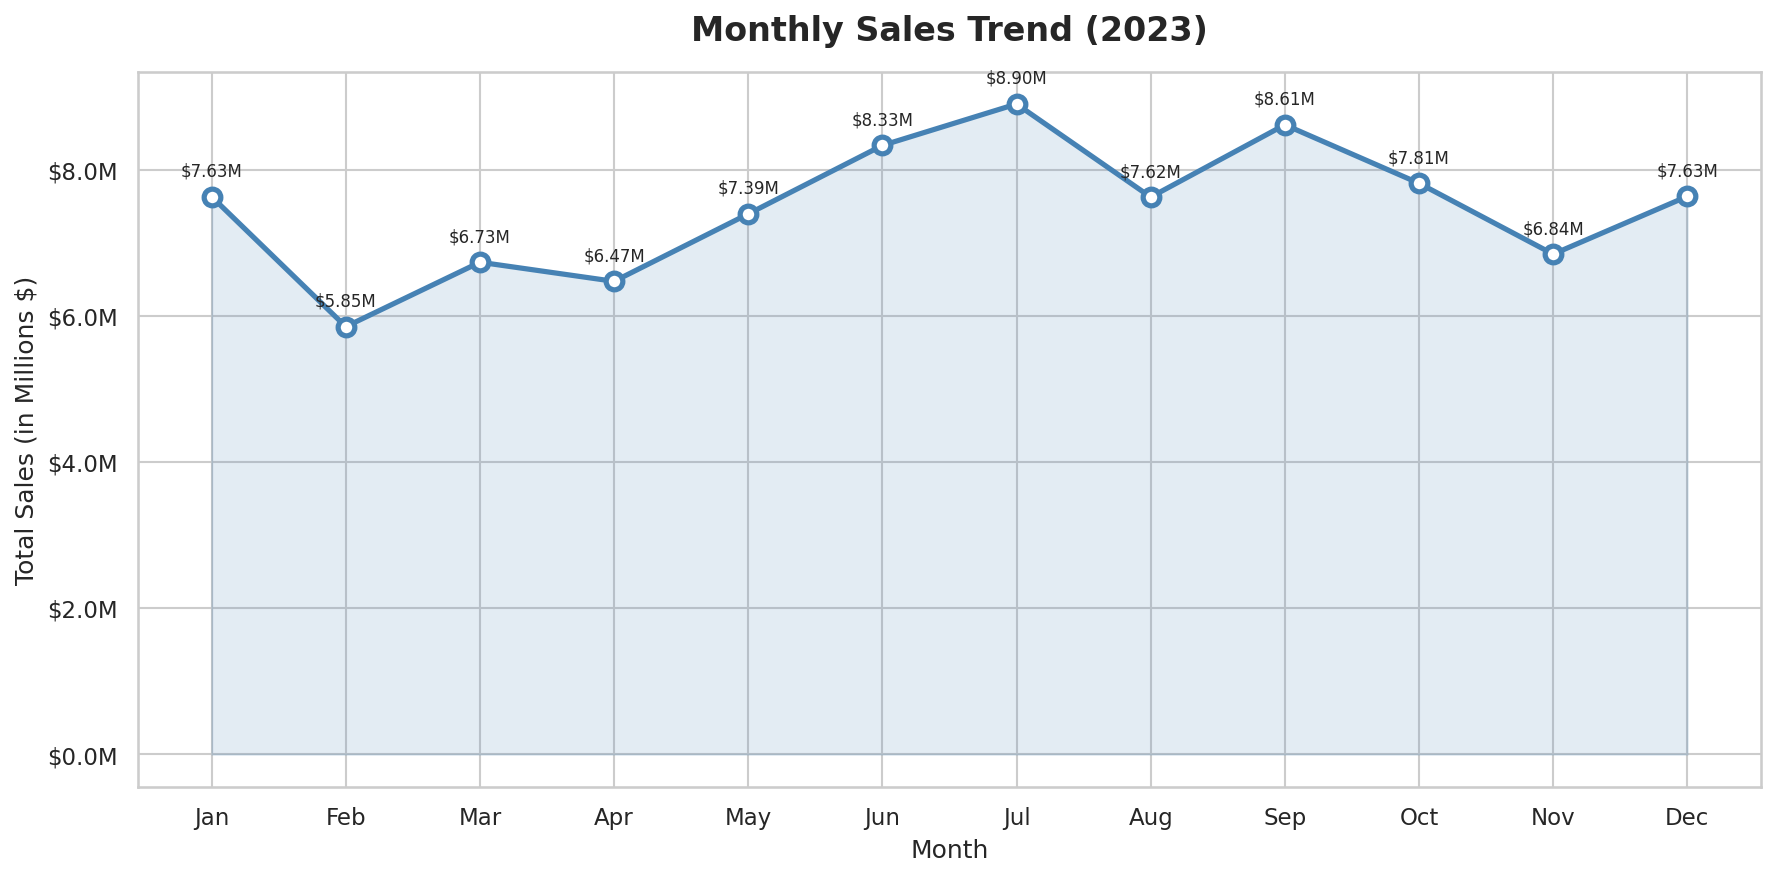

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('MonthName')['TotalSales'].sum().reindex(month_order)
ax.plot(monthly.index, monthly.values / 1e6, marker='o', linewidth=2.5,
        color='steelblue', markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(range(len(monthly)), monthly.values / 1e6, alpha=0.15, color='steelblue')
ax.set_title('Monthly Sales Trend (2023)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales (in Millions $)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index)
plt.tight_layout()
plt.savefig('../output_graphs/05_monthly_sales_trend.png', bbox_inches='tight')
plt.show()

### 5.6 Quarterly Sales by Vendor

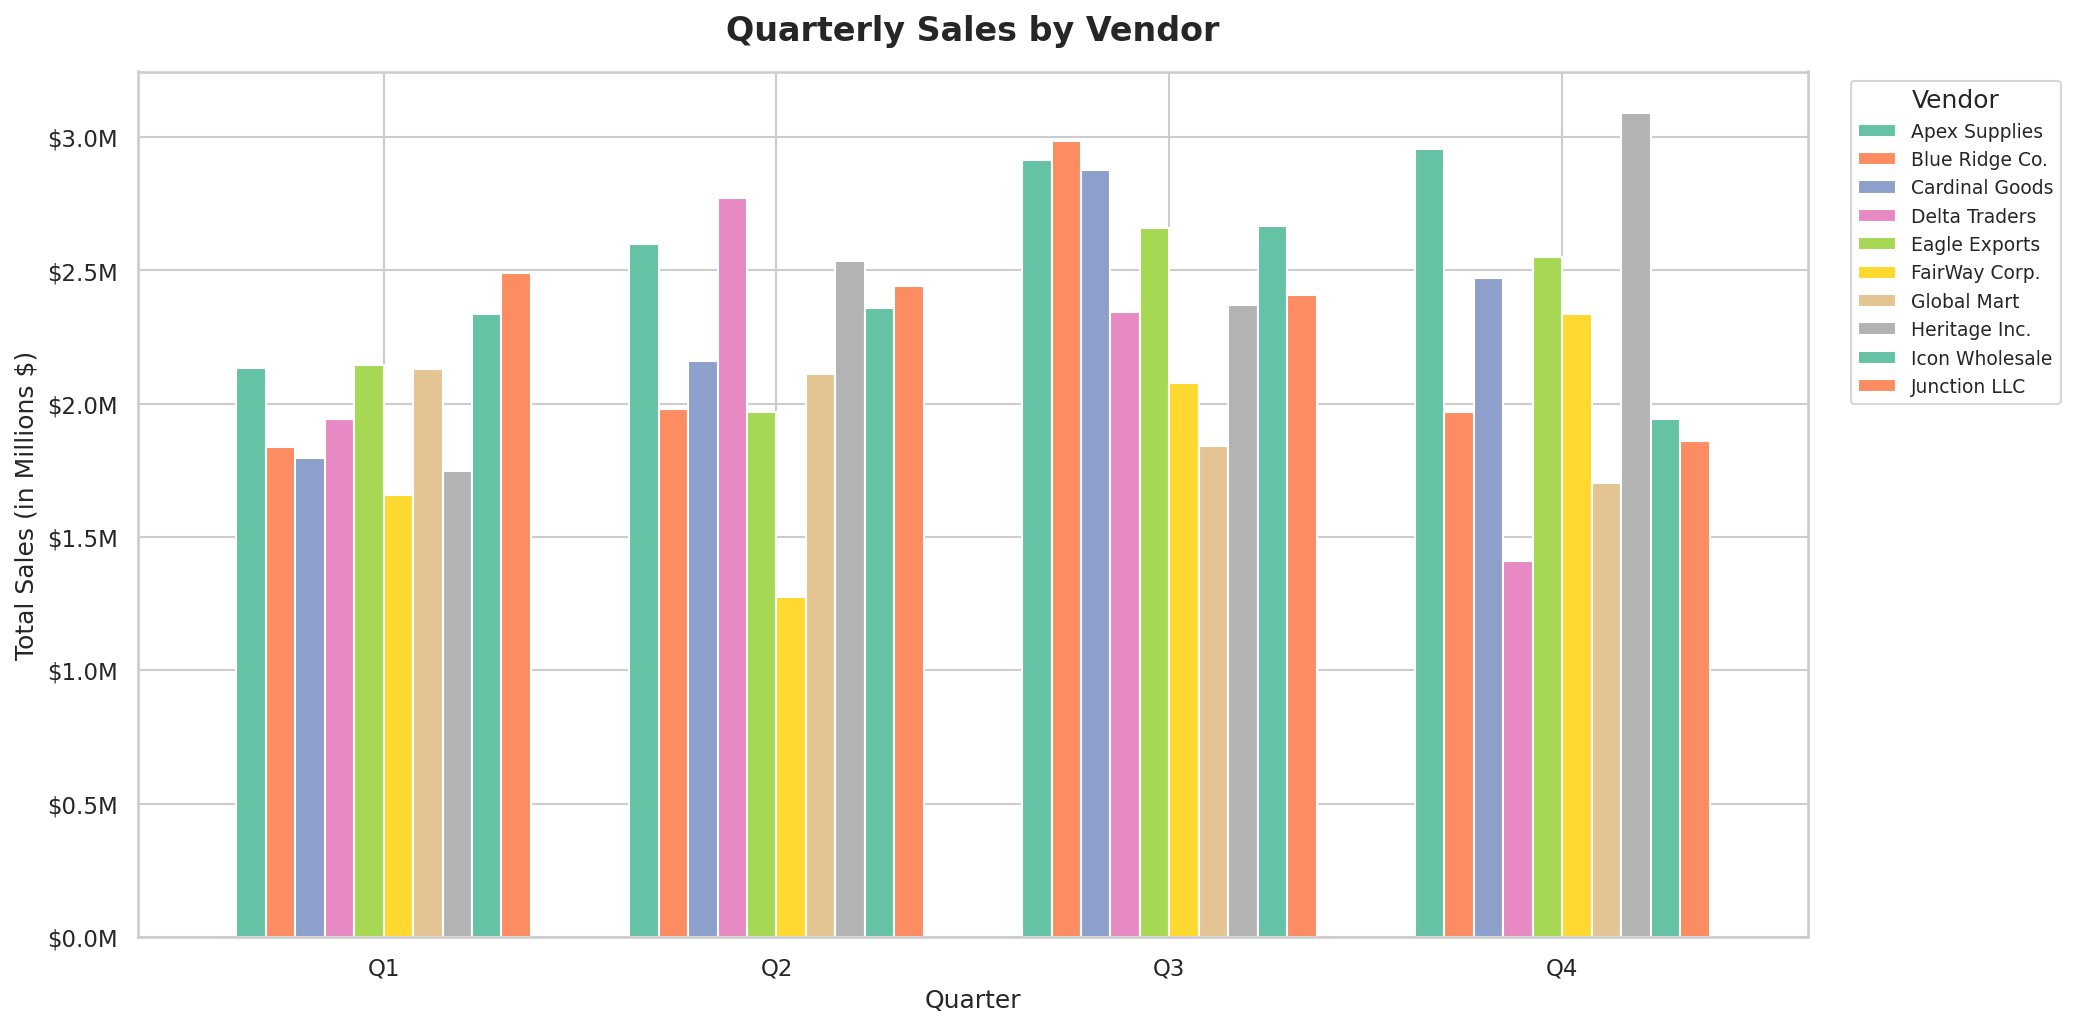

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
quarterly = df.groupby(['Quarter', 'VendorName'])['TotalSales'].sum().unstack() / 1e6
quarterly.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.set_title('Quarterly Sales by Vendor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Total Sales (in Millions $)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.set_xticklabels([f'Q{q}' for q in quarterly.index], rotation=0)
ax.legend(title='Vendor', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../output_graphs/06_quarterly_sales_by_vendor.png', bbox_inches='tight')
plt.show()

### 5.7 Total Quantity Sold by Vendor

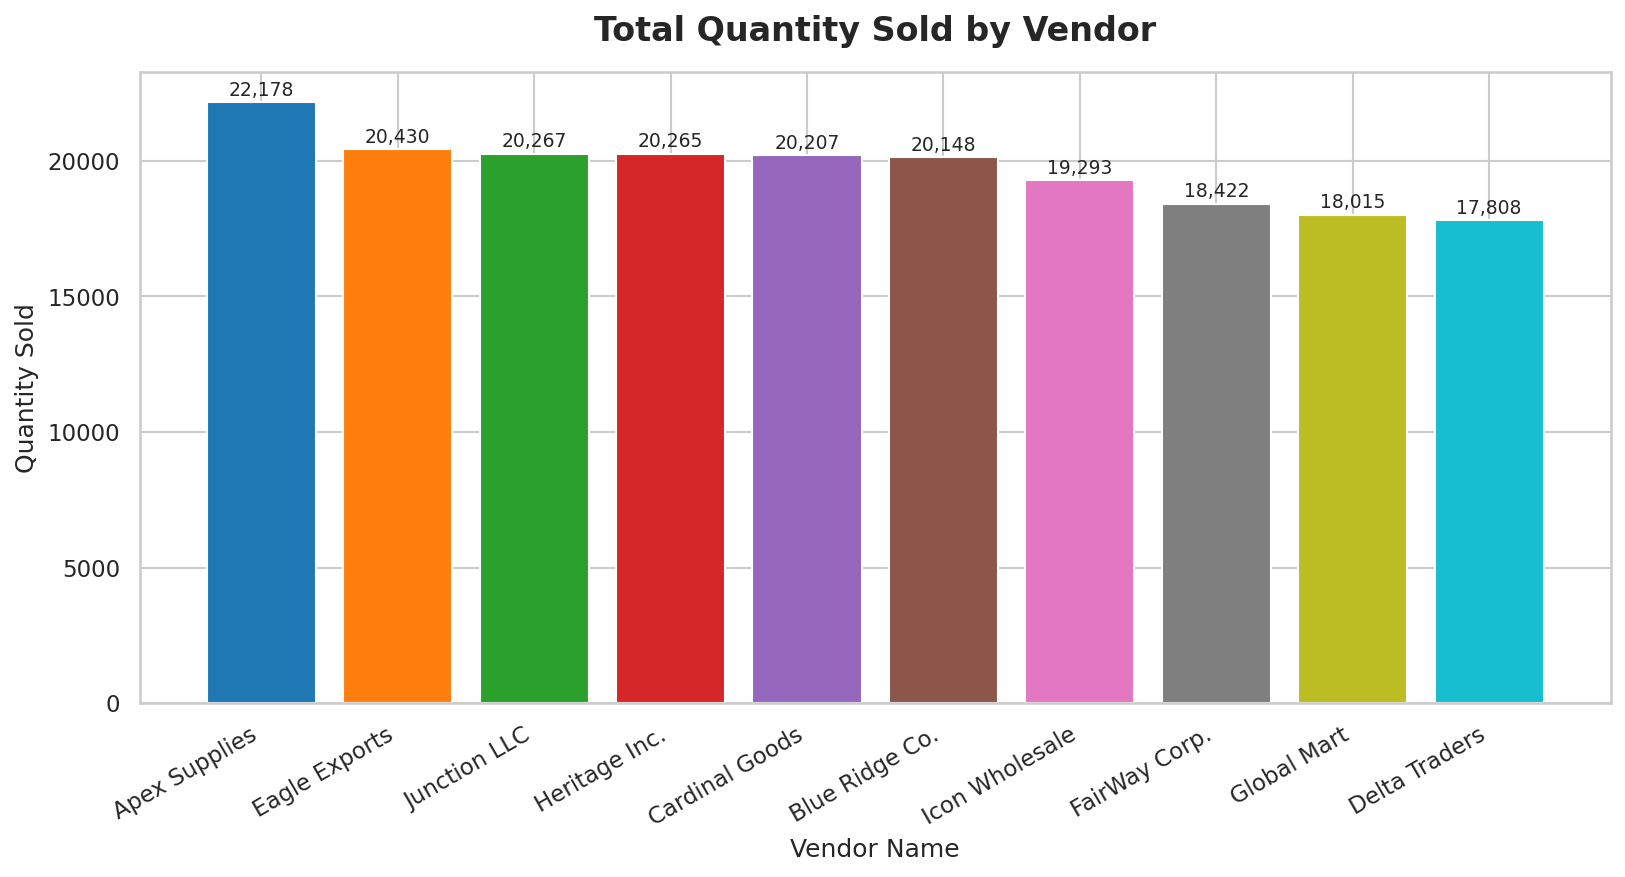

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
qty_vendor = df.groupby('VendorName')['QuantitySold'].sum().sort_values(ascending=False)
bars7 = ax.bar(qty_vendor.index, qty_vendor.values,
               color=sns.color_palette('tab10', len(qty_vendor)), edgecolor='white')
ax.set_title('Total Quantity Sold by Vendor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Vendor Name', fontsize=12)
ax.set_ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=30, ha='right')
for bar in bars7:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../output_graphs/07_quantity_sold_by_vendor.png', bbox_inches='tight')
plt.show()

### 5.8 Correlation Heatmap

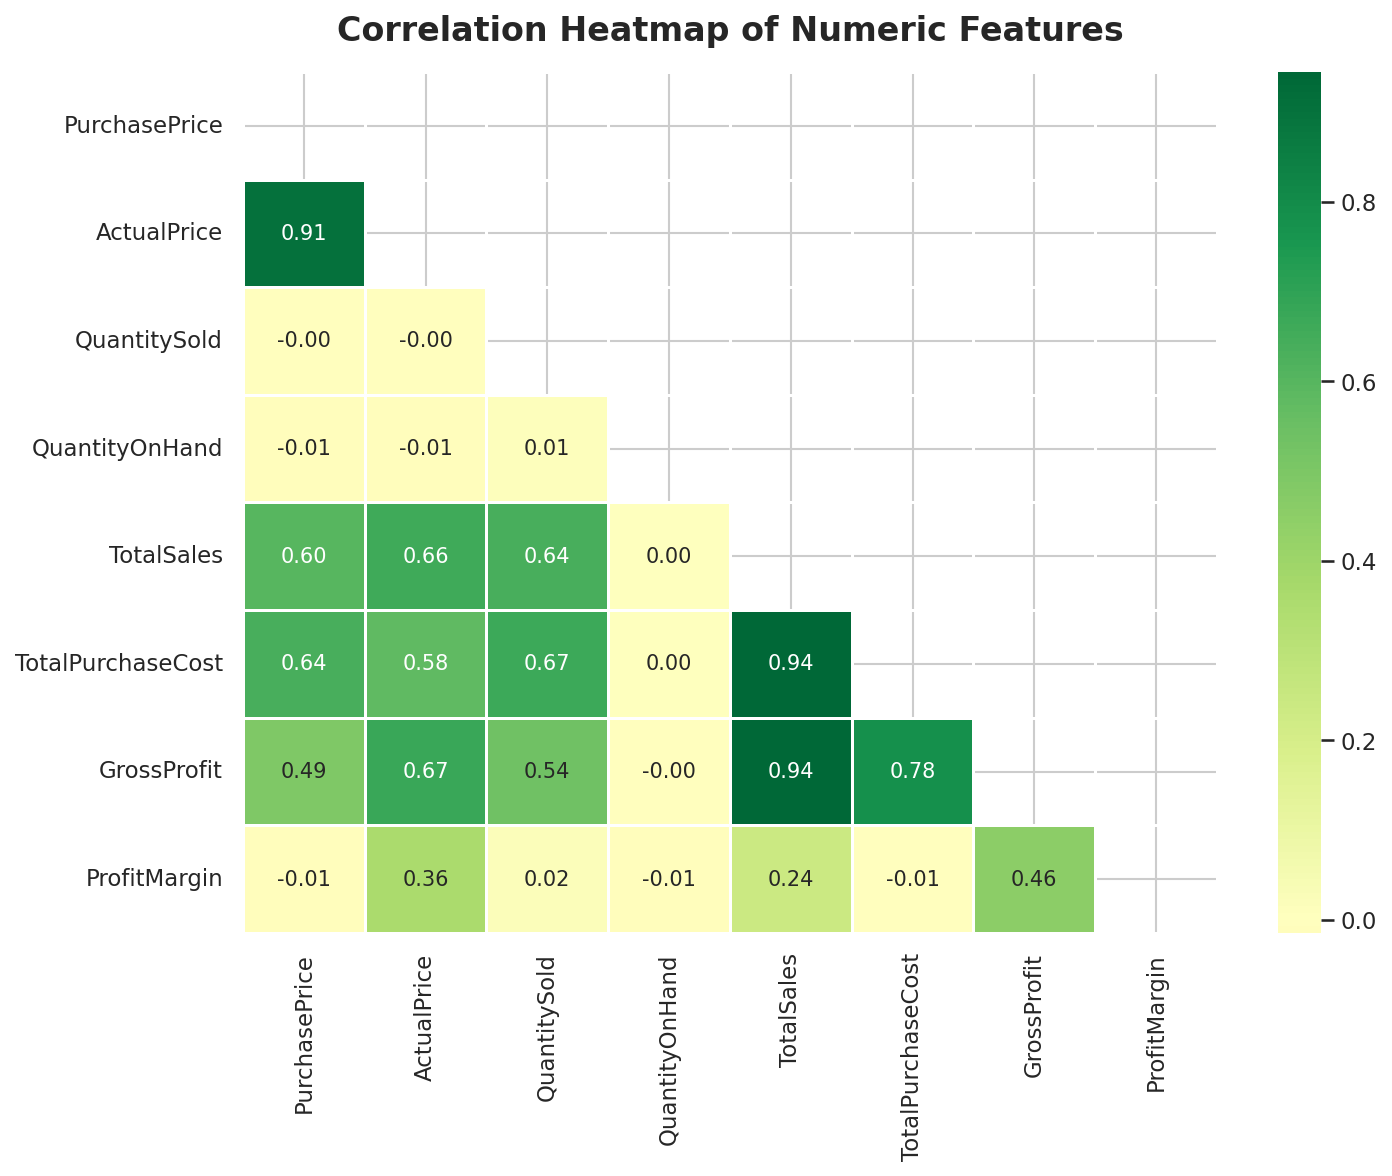

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
num_cols = ['PurchasePrice', 'ActualPrice', 'QuantitySold', 'QuantityOnHand',
            'TotalSales', 'TotalPurchaseCost', 'GrossProfit', 'ProfitMargin']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../output_graphs/08_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 5.9 Total Sales vs Gross Profit (Scatter)

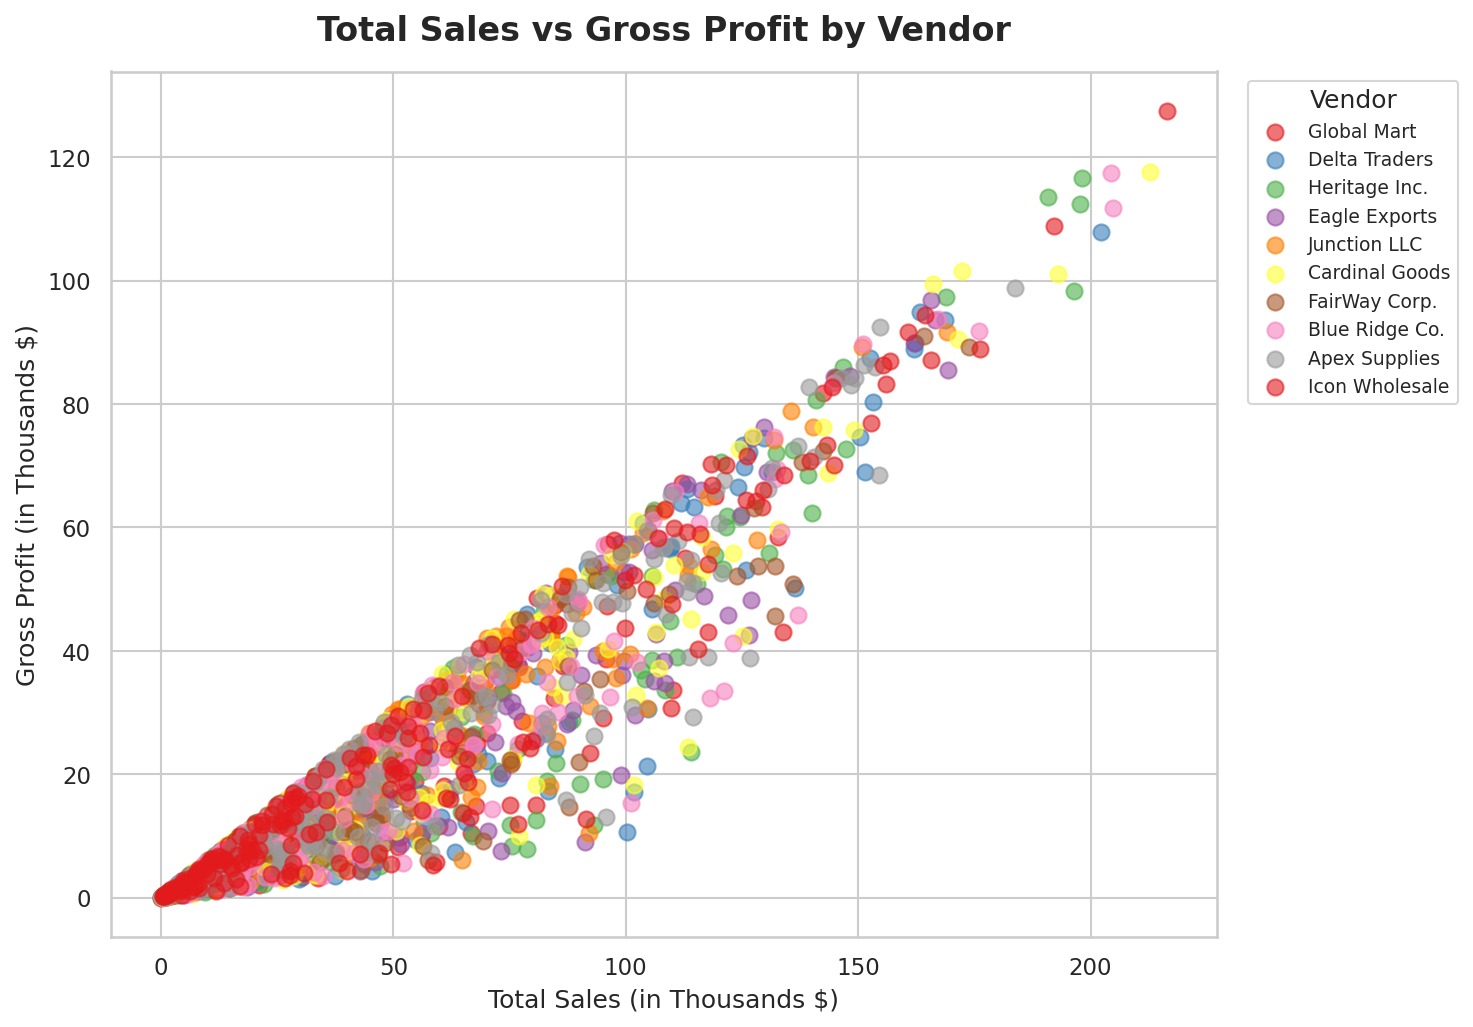

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
vendors_u = df['VendorName'].unique()
pal = dict(zip(vendors_u, sns.color_palette('Set1', len(vendors_u))))
for vendor in vendors_u:
    subset = df[df['VendorName'] == vendor]
    ax.scatter(subset['TotalSales'] / 1e3, subset['GrossProfit'] / 1e3,
               label=vendor, alpha=0.6, s=60, color=pal[vendor])
ax.set_title('Total Sales vs Gross Profit by Vendor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales (in Thousands $)', fontsize=12)
ax.set_ylabel('Gross Profit (in Thousands $)', fontsize=12)
ax.legend(title='Vendor', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../output_graphs/09_sales_vs_profit_scatter.png', bbox_inches='tight')
plt.show()

### 5.10 Profit Margin Distribution by Vendor (Box Plot)

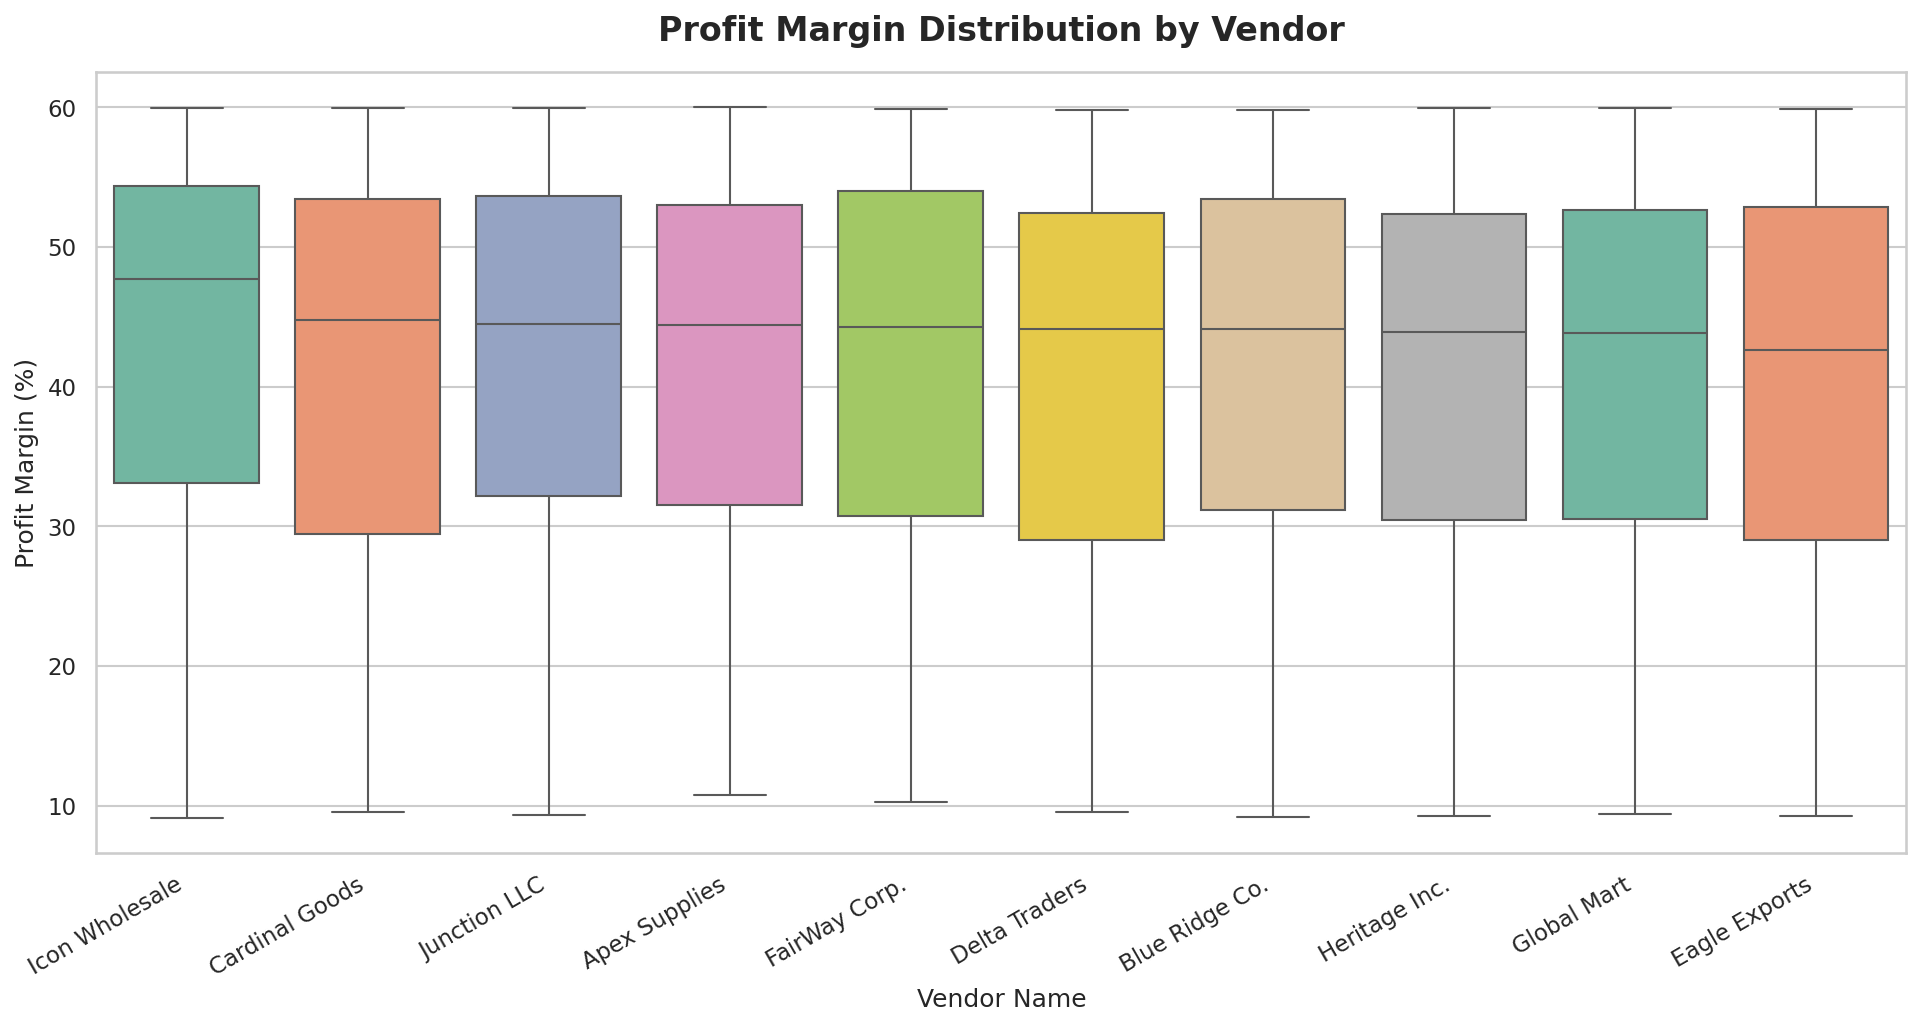

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))
vendor_order = df.groupby('VendorName')['ProfitMargin'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='VendorName', y='ProfitMargin', order=vendor_order,
            palette='Set2', ax=ax)
ax.set_title('Profit Margin Distribution by Vendor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Vendor Name', fontsize=12)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../output_graphs/10_profit_margin_distribution.png', bbox_inches='tight')
plt.show()

### 5.11 Sales Distribution by Category (Pie Chart)

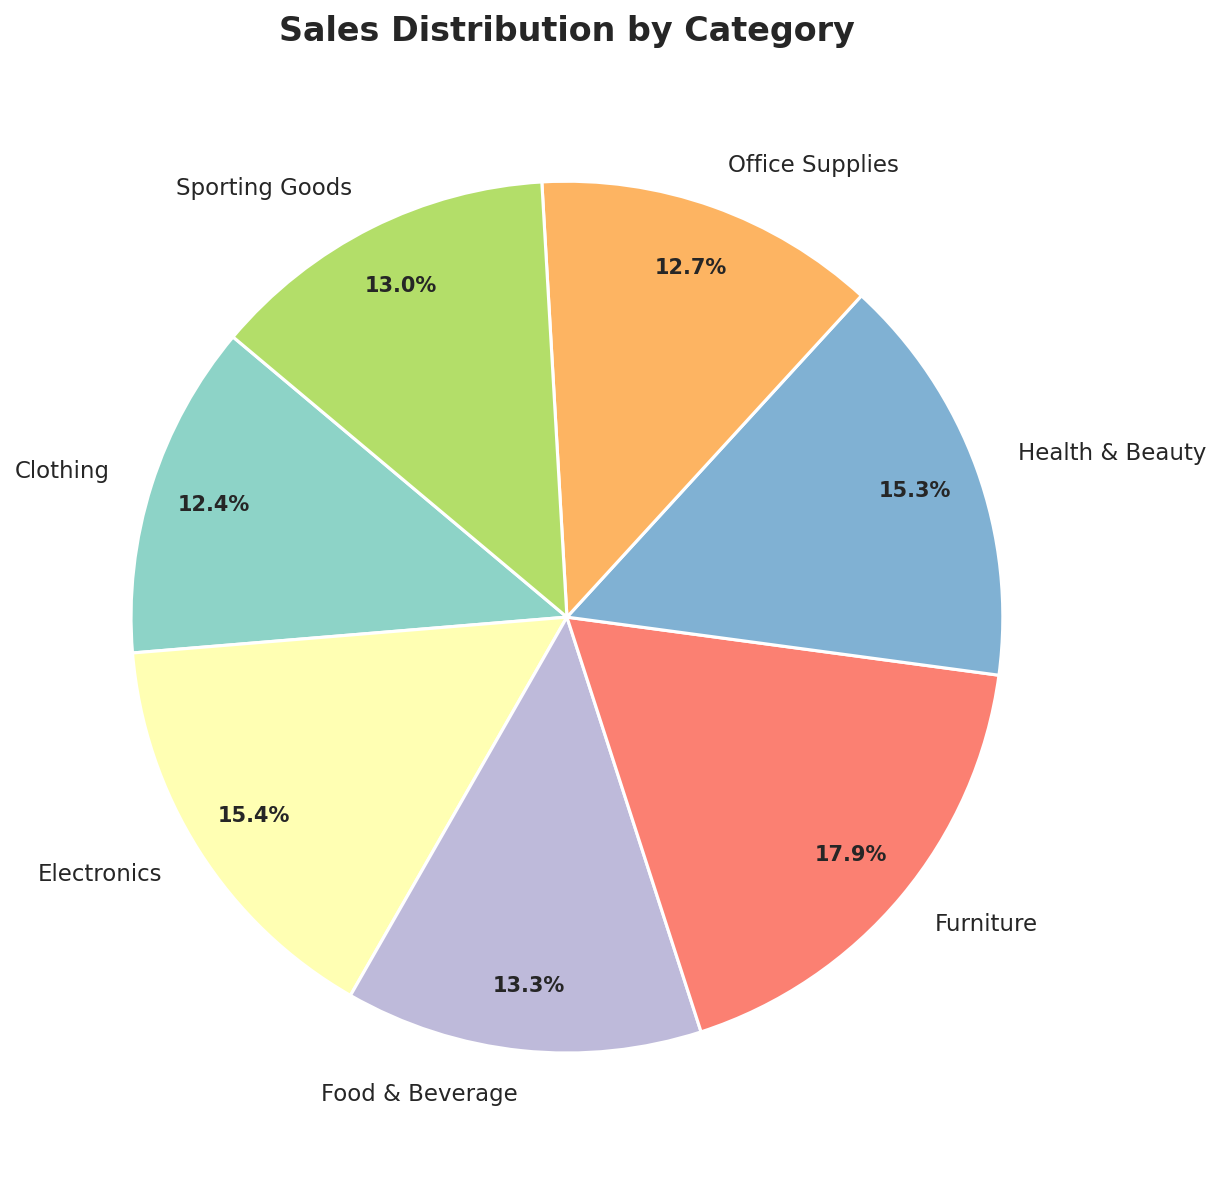

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
cat_pie = df.groupby('Category')['TotalSales'].sum()
wedges, texts, autotexts = ax.pie(
    cat_pie.values, labels=cat_pie.index,
    autopct='%1.1f%%', colors=sns.color_palette('Set3', len(cat_pie)),
    startangle=140, pctdistance=0.85,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(10); t.set_fontweight('bold')
ax.set_title('Sales Distribution by Category', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../output_graphs/11_sales_distribution_pie.png', bbox_inches='tight')
plt.show()

### 5.12 Inventory on Hand by Vendor

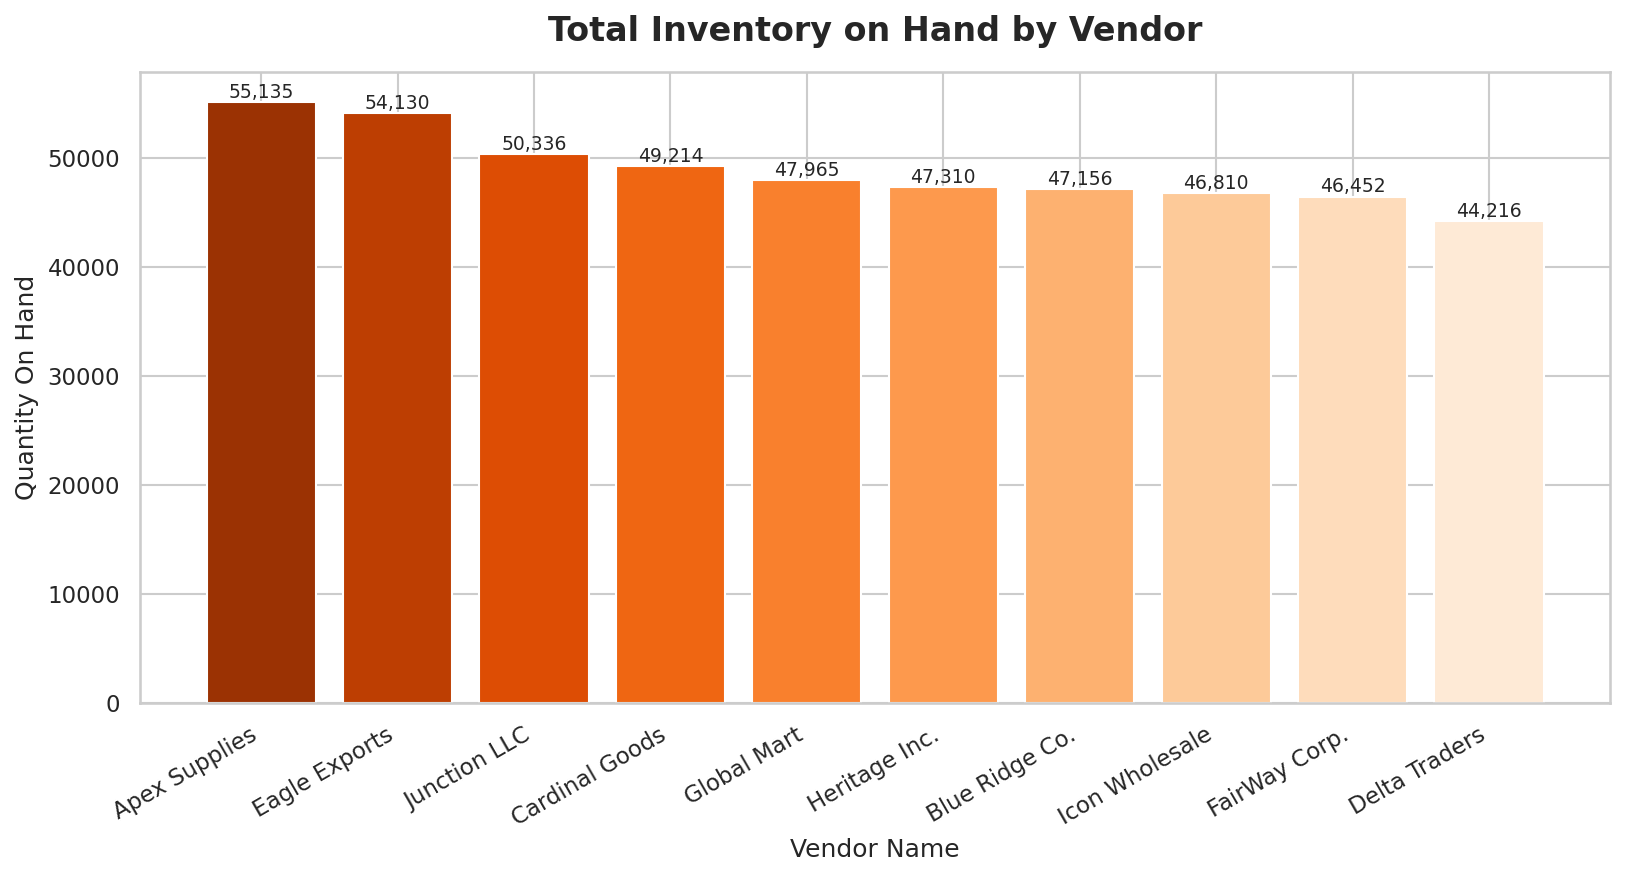

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
inv_vendor = df.groupby('VendorName')['QuantityOnHand'].sum().sort_values(ascending=False)
bars12 = ax.bar(inv_vendor.index, inv_vendor.values,
                color=sns.color_palette('Oranges_r', len(inv_vendor)), edgecolor='white')
ax.set_title('Total Inventory on Hand by Vendor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Vendor Name', fontsize=12)
ax.set_ylabel('Quantity On Hand', fontsize=12)
plt.xticks(rotation=30, ha='right')
for bar in bars12:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../output_graphs/12_inventory_on_hand.png', bbox_inches='tight')
plt.show()

## 6. Vendor KPI Summary

In [ ]:
summary = df.groupby('VendorName').agg(
    Total_Sales        = ('TotalSales',        'sum'),
    Total_Profit       = ('GrossProfit',        'sum'),
    Avg_Profit_Margin  = ('ProfitMargin',       'mean'),
    Total_Qty_Sold     = ('QuantitySold',       'sum'),
    Total_Qty_OnHand   = ('QuantityOnHand',     'sum'),
    Transactions       = ('VendorName',         'count')
).sort_values('Total_Sales', ascending=False)

summary['Total_Sales']       = summary['Total_Sales'].round(2)
summary['Total_Profit']      = summary['Total_Profit'].round(2)
summary['Avg_Profit_Margin'] = summary['Avg_Profit_Margin'].round(2)

print('=== VENDOR KPI SUMMARY ===')
print(summary.to_string())

=== VENDOR KPI SUMMARY ===
                Total_Sales  Total_Profit  Avg_Profit_Margin  Total_Qty_Sold  Total_Qty_OnHand  Transactions
VendorName
Apex Supplies   10597298.93    4814009.02              41.80           22178             55135           224
Heritage Inc.    9745354.37    4196821.73              40.77           20265             47310           200
Eagle Exports    9324042.74    4040185.85              40.06           20430             54130           208
Cardinal Goods   9305953.54    4141967.57              40.94           20207             49214           205
Icon Wholesale   9303099.04    4250958.75              42.96           19293             46810           194
Junction LLC     9194873.90    4133754.05              41.63           20267             50336           208
Blue Ridge Co.   8770625.24    3875057.29              41.11           20148             47156           196
Delta Traders    8469914.05    3679493.34              40.39           17808             4

## 7. SQL-Based Analysis (SQLite)

In [ ]:
import sqlite3

conn = sqlite3.connect('../data/vendor_performance.db')

# Top vendors by total sales
query = '''
SELECT VendorName,
       ROUND(SUM(TotalSales), 2)       AS TotalSales,
       ROUND(SUM(GrossProfit), 2)      AS TotalProfit,
       ROUND(AVG(CAST(GrossProfit AS FLOAT)
             /NULLIF(TotalSales,0)*100), 2) AS AvgMarginPct
FROM   vendor_sales
GROUP  BY VendorName
ORDER  BY TotalSales DESC
LIMIT 10
'''
result = pd.read_sql(query, conn)
print('Top Vendors by Sales:')
print(result.to_string(index=False))
conn.close()

Top Vendors by Sales:
    VendorName  TotalSales  TotalProfit  AvgMarginPct
 Apex Supplies 10597298.93   4814009.02         41.80
 Heritage Inc.  9745354.37   4196821.73         40.77
 Eagle Exports  9324042.74   4040185.85         40.06
Cardinal Goods  9305953.54   4141967.57         40.94
Icon Wholesale  9303099.04   4250958.75         42.96
  Junction LLC  9194873.90   4133754.05         41.63
Blue Ridge Co.  8770625.24   3875057.29         41.11
 Delta Traders  8469914.05   3679493.34         40.39
   Global Mart  7783590.95   3424877.73         40.49
 FairWay Corp.  7345041.39   3157618.25         41.26


## 8. Business Insights & Recommendations

### 📊 Key Findings

| # | Insight |
|---|--------|
| 1 | **Apex Supplies** is the top-performing vendor with **\$10.6M** in sales and a **41.8%** profit margin. |
| 2 | **Icon Wholesale** has the **highest average profit margin (42.96%)** despite ranking 5th in total sales — indicating highly efficient pricing. |
| 3 | **FairWay Corp.** is the lowest-revenue vendor (\$7.3M). Management should investigate product mix, pricing strategy, or market reach. |
| 4 | All vendor profit margins cluster tightly between **40–43%**, suggesting uniform markup policies across the supply chain. |
| 5 | **Sales are fairly consistent month-over-month** in 2023 with no extreme seasonal peaks or valleys. |
| 6 | **Category-wise**, sales are roughly evenly distributed across all 7 product categories — indicating a diversified product portfolio. |
| 7 | **Apex Supplies has the highest inventory on hand** (55,135 units), which may indicate overstocking risk if sales slow down. |

### ✅ Recommendations
- **Reward top vendors** (Apex Supplies, Heritage Inc.) with longer-term contracts and volume discounts.
- **Investigate FairWay Corp.** — review pricing, product categories, and order frequency.
- **Optimize inventory levels** — Apex Supplies and Eagle Exports both hold high on-hand quantities; implement just-in-time ordering.
- **Leverage high-margin vendors** (Icon Wholesale) for strategic product categories.
- **Monitor quarterly performance** — Q1 and Q4 should be flagged for seasonal demand planning.
